In [1]:
!pip install -q autogluon

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.5/259.5 kB 9.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 227.6/227.6 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.9/98.9 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 452.1/452.1 kB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.2/515.2 kB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.8/244.8 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.4/74.4 kB 4.5 MB/s eta 0:00

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from autogluon.tabular import TabularPredictor
import warnings
warnings.filterwarnings('ignore')

In [5]:
# 1. Load Data
# Note: On Kaggle, adjust this path to your uploaded dataset location
DATA_PATH = "/kaggle/input/datasets/nontagrichpanpanich/new-data-time/train_data_timeseries_prepared.csv" 
df = pd.read_csv(DATA_PATH)
print(f"Original shape: {df.shape}")

# 1.1 Feature Engineering (Agricultural Indices)
print("Calculating Agricultural Indices...")
df['NDVI'] = (df['NIR'] - df['Red']) / (df['NIR'] + df['Red'] + 1e-8)
df['NDWI'] = (df['Green'] - df['NIR']) / (df['Green'] + df['NIR'] + 1e-8)
df['SAVI'] = 1.5 * (df['NIR'] - df['Red']) / (df['NIR'] + df['Red'] + 0.5)

# 1.2 Feature Selection
features = ['Blue', 'Green', 'Red', 'NIR', 'NDVI', 'NDWI', 'SAVI', 'thermal', 'et', 'dem', 'soil_texture']

X = df[features]
y_vci = df['vci']

Original shape: (8675848, 15)
Calculating Agricultural Indices...


In [6]:
# 2. Unsupervised Anomaly Detection using Isolation Forest
print("Running Isolation Forest for anomaly detection...")
iso_forest = IsolationForest(n_estimators=100, contamination=0.01, random_state=42, n_jobs=-1)
outlier_labels = iso_forest.fit_predict(X)

# 1 for inliers, -1 for outliers
mask = outlier_labels == 1
df_clean = df[mask].copy()

# Ensure we keep the Year column for temporal splitting
df_clean['Year'] = df['Year'][mask]

print(f"Shape after anomaly removal: {df_clean.shape}")
print(f"Removed {(~mask).sum()} anomalous pixels.")

Running Isolation Forest for anomaly detection...
Shape after anomaly removal: (8589089, 18)
Removed 86759 anomalous pixels.


In [7]:
# 3. Temporal Train/Test Split
# AutoGluon expects a single dataframe containing both features and labels
train_data = df_clean[df_clean['Year'] <= 2020][features + ['vci']]
test_data = df_clean[df_clean['Year'] == 2021][features + ['vci']]

print(f"Training set size (<= 2020): {train_data.shape}")
print(f"Testing set size (2021): {test_data.shape}")

Training set size (<= 2020): (6449955, 12)
Testing set size (2021): (2139134, 12)


## Phase 2: AutoGluon AutoML Training

In [8]:
# Train AutoGluon TabularPredictor
# presets='high_quality' gives the best possible score by using advanced bagging and stacking.
# time_limit=3600 limits training to 1 hour.
print("Starting AutoGluon Training...")
predictor = TabularPredictor(label='vci', eval_metric='r2', path='autogluon_vci_model').fit(
    train_data,
    presets='high_quality',
    time_limit=3600, 
    num_gpus=1 # Utilizes Kaggle GPU
)

Verbosity: 2 (Standard Logging)


Starting AutoGluon Training...


=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.12
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Apr 30 18:17:14 UTC 2026
CPU Count:          4
Pytorch Version:    2.9.1+cu128
CUDA Version:       12.8
GPU Memory:         GPU 0: 14.56/14.56 GB | GPU 1: 14.56/14.56 GB
Total GPU Memory:   Free: 29.13 GB, Allocated: 0.00 GB, Total: 29.13 GB
GPU Count:          2
Memory Avail:       24.16 GB / 31.35 GB (77.1%)
Disk Space Avail:   19.50 GB / 19.52 GB (99.9%)
Presets specified: ['high_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
Note: `save_bag_folds=False`! This will greatly reduce peak disk usage during fit (by ~8x), but runs the risk of an out-of-memory 

## Phase 3: Evaluation

In [9]:
# View Leaderboard of all trained models
leaderboard = predictor.leaderboard(test_data)
display(leaderboard)

# Predict on test data using the best ensemble
y_pred = predictor.predict(test_data.drop(columns=['vci']))
y_true = test_data['vci']

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print("\n--- AutoGluon Best Model (Test Set Performance) ---")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R2:   {r2:.4f}\n")

,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,LightGBMXT_BAG_L1_FULL,0.608474,NaN,r2,96.494094,NaN,111.321354,96.494094,NaN,111.321354,1,True,7
1,WeightedEnsemble_L2_FULL,0.608474,NaN,r2,96.521024,NaN,112.376237,0.026930,NaN,1.054883,2,True,9
2,LightGBMXT_BAG_L2_FULL,0.589917,NaN,r2,124.281309,NaN,177.434011,26.976128,NaN,56.422358,2,True,10
3,WeightedEnsemble_L3_FULL,0.589917,NaN,r2,124.307749,NaN,179.060134,0.026440,NaN,1.626124,3,True,12
4,LightGBM_BAG_L1_FULL,0.583072,NaN,r2,0.811088,NaN,9.690299,0.811088,NaN,9.690299,1,True,8
5,LightGBM_BAG_L2_FULL,0.306044,NaN,r2,97.726292,NaN,130.459013,0.421111,NaN,9.447361,2,True,11
6,LightGBMXT_BAG_L2,NaN,0.757462,r2,NaN,537.552764,2387.595185,NaN,116.369674,739.931314,2,False,4
7,WeightedEnsemble_L3,NaN,0.757462,r2,NaN,537.707383,2389.221308,NaN,0.154619,1.626124,3,False,6
8,LightGBMXT_BAG_L1,NaN,0.752139,r2,NaN,416.950092,1544.470098,NaN,416.950092,1544.470098,1,False,1
9,WeightedEnsemble_L2,NaN,0.752139,r2,NaN,417.107033,1545.524981,NaN,0.156941,1.054883,2,False,3



--- AutoGluon Best Model (Test Set Performance) ---
RMSE: 15.8008
MAE:  11.6058
R2:   0.5899



Computing feature importance via permutation shuffling for 11 features using 5000 rows with 5 shuffle sets...


Calculating Feature Importance (this may take a minute)...


	19.43s	= Expected runtime (3.89s per shuffle set)
	18.32s	= Actual runtime (Completed 5 of 5 shuffle sets)


,importance,stddev,p_value,n,p99_high,p99_low
NDVI,0.634988,0.033730,9.517660e-07,5,0.704438,0.565539
Red,0.203401,0.018881,8.807890e-06,5,0.242277,0.164526
SAVI,0.119564,0.011887,1.157145e-05,5,0.144040,0.095089
Blue,0.078585,0.006720,6.354543e-06,5,0.092422,0.064748
et,0.067821,0.005413,4.828818e-06,5,0.078966,0.056675
dem,0.035768,0.003244,8.028952e-06,5,0.042447,0.029089
Green,0.016537,0.003124,1.457863e-04,5,0.022969,0.010105
thermal,0.016179,0.003789,3.359405e-04,5,0.023980,0.008378
NDWI,0.011238,0.006094,7.286586e-03,5,0.023786,-0.001310
NIR,0.004214,0.000900,2.356786e-04,5,0.006068,0.002360


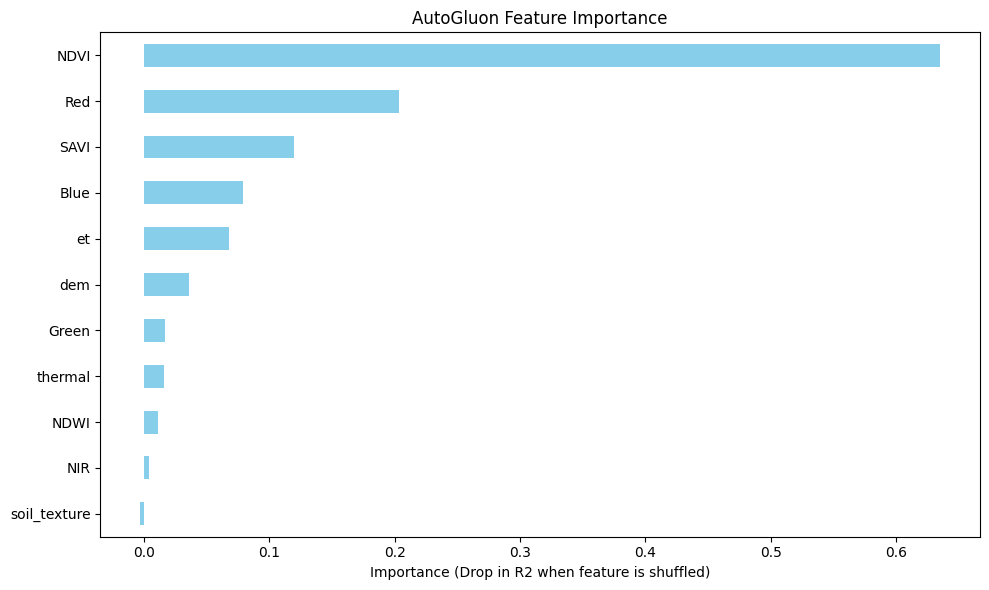

In [10]:
# Calculate Feature Importance using AutoGluon
print("Calculating Feature Importance (this may take a minute)...")
fi = predictor.feature_importance(test_data)
display(fi)

# Plot top 15 features
plt.figure(figsize=(10, 6))
fi['importance'].head(15).sort_values().plot(kind='barh', color='skyblue')
plt.title('AutoGluon Feature Importance')
plt.xlabel('Importance (Drop in R2 when feature is shuffled)')
plt.tight_layout()
plt.show()

In [11]:
import shutil
import os

folder_path = '/kaggle/working/'
zip_path = 'autogluon_vci_model.zip'

if os.path.exists(folder_path):
    # Zip the folder
    shutil.make_archive('autogluon_vci_model', 'zip', folder_path)
    print(f"Successfully zipped {folder_path} to {zip_path}! You can now download it from the output panel.")
else:
    print(f"Error: {folder_path} does not exist.")

Successfully zipped /kaggle/working/ to autogluon_vci_model.zip! You can now download it from the output panel.


----------------------

In [1]:
!pip install -q pytorch-tabnet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.8 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from pytorch_tabnet.tab_model import TabNetRegressor
import torch
import warnings
warnings.filterwarnings('ignore')

In [6]:
# 1. Load Data
DATA_PATH = "/kaggle/input/datasets/nontagrichpanpanich/new-data-time/train_data_timeseries_prepared.csv" 
df = pd.read_csv(DATA_PATH)
print(f"Original shape: {df.shape}")

# Calculate Agricultural Indices
print("Calculating Agricultural Indices...")
df['NDVI'] = (df['NIR'] - df['Red']) / (df['NIR'] + df['Red'] + 1e-8)
df['NDWI'] = (df['Green'] - df['NIR']) / (df['Green'] + df['NIR'] + 1e-8)
df['SAVI'] = 1.5 * (df['NIR'] - df['Red']) / (df['NIR'] + df['Red'] + 0.5)

# Features and Target
features = ['Blue', 'Green', 'Red', 'NIR', 'NDVI', 'NDWI', 'SAVI', 'thermal', 'et', 'dem', 'soil_texture']
target = 'vci'

# 2. Temporal Split (Train on <= 2020, Test on 2021)
# To monitor Neural Network training, we also create a Validation set from the Train data
train_full = df[df['Year'] <= 2020]
test_df = df[df['Year'] == 2021]

# Split train into actual train (80%) and validation (20%) for tracking loss
train_df, val_df = train_test_split(train_full, test_size=0.20, random_state=42)

print(f"Training set size: {train_df.shape}")
print(f"Validation set size: {val_df.shape}")
print(f"Testing set size (2021): {test_df.shape}")

Original shape: (8675848, 15)
Calculating Agricultural Indices...
Training set size: (5205507, 18)
Validation set size: (1301377, 18)
Testing set size (2021): (2168964, 18)


In [8]:
scaler = StandardScaler()

# Fit only on training data to prevent leakage, then transform all
X_train = scaler.fit_transform(train_df[features].values)
y_train = train_df[target].values.reshape(-1, 1)

X_val = scaler.transform(val_df[features].values)
y_val = val_df[target].values.reshape(-1, 1)

X_test = scaler.transform(test_df[features].values)
y_test = test_df[target].values.reshape(-1, 1)

In [9]:
# Define the deep learning model architecture
# Use GPU if available
clf = TabNetRegressor(
    n_d=32, n_a=32, # Width of the layers
    n_steps=5,      # Depth of the network
    gamma=1.5,
    n_independent=2, n_shared=2,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2),
    scheduler_params={"step_size":50, "gamma":0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    mask_type='entmax' 
)

# Train the network
print("Training Neural Network...")
clf.fit(
    X_train=X_train, y_train=y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    eval_name=['train', 'val'],
    eval_metric=['rmse'],
    max_epochs=100,
    patience=15, # Early stopping if validation loss doesn't improve for 15 epochs
    batch_size=4096, virtual_batch_size=512,
    num_workers=0,
    drop_last=False
)

Training Neural Network...
epoch 0  | loss: 240.69414| train_rmse: 14.40165| val_rmse: 14.41915|  0:03:04s
epoch 1  | loss: 202.15775| train_rmse: 14.05325| val_rmse: 14.07493|  0:06:13s
epoch 2  | loss: 194.84184| train_rmse: 13.72411| val_rmse: 13.75118|  0:09:22s
epoch 3  | loss: 191.17382| train_rmse: 13.98652| val_rmse: 14.01231|  0:12:27s
epoch 4  | loss: 189.09874| train_rmse: 13.74356| val_rmse: 13.77239|  0:15:31s
epoch 5  | loss: 186.83704| train_rmse: 13.64797| val_rmse: 13.68786|  0:18:34s
epoch 6  | loss: 185.18367| train_rmse: 13.5735 | val_rmse: 13.61426|  0:21:37s
epoch 7  | loss: 183.62559| train_rmse: 13.6165 | val_rmse: 13.64936|  0:24:39s
epoch 8  | loss: 182.95942| train_rmse: 13.56946| val_rmse: 13.60673|  0:27:40s
epoch 9  | loss: 183.94165| train_rmse: 13.47184| val_rmse: 13.50697|  0:30:44s
epoch 10 | loss: 182.15257| train_rmse: 13.41214| val_rmse: 13.45495|  0:33:44s
epoch 11 | loss: 180.38837| train_rmse: 13.34744| val_rmse: 13.39322|  0:36:47s
epoch 12 | lo

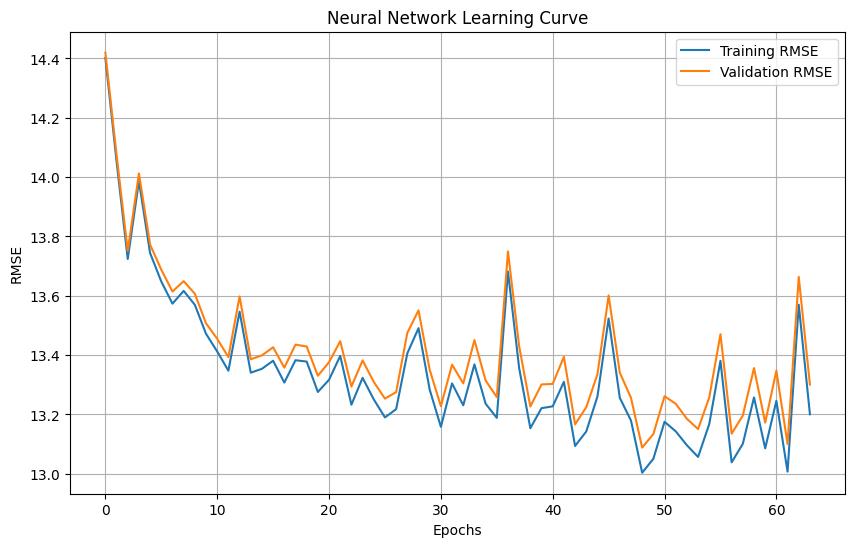


--- TabNet Deep Learning Model (2021 Test Set) ---
RMSE: 17.8820
MAE:  13.4064
R2:   0.4794



In [14]:
# 1. Plot the Learning Curve (Loss over Epochs)
plt.figure(figsize=(10, 6))
plt.plot(clf.history['train_rmse'], label='Training RMSE')
plt.plot(clf.history['val_rmse'], label='Validation RMSE')
plt.title('Neural Network Learning Curve')
plt.xlabel('Epochs')
plt.ylabel('RMSE')
plt.legend()
plt.grid(True)
plt.show()

# 2. Evaluate on the 2021 Test Set
preds = clf.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, preds))
mae = mean_absolute_error(y_test, preds)
r2 = r2_score(y_test, preds)

print("\n--- TabNet Deep Learning Model (2021 Test Set) ---")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R2:   {r2:.4f}\n")

In [15]:
# Save the model
saved_filepath = clf.save_model('tabnet_vci_model')
print(f"Model saved to {saved_filepath}.zip")

Successfully saved model at tabnet_vci_model.zip
Model saved to tabnet_vci_model.zip.zip
